In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (6, 6)

In [20]:
dataset_path = "dataset/dataset/faces"

faces = []
labels = []
names = []

for person in sorted(os.listdir(dataset_path)):

    if person.startswith("."):
        continue

    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    names.append(person)
    label = len(names) - 1

    for img_name in os.listdir(person_path):

        img_path = os.path.join(person_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (100, 100))

        faces.append(img.flatten())
        labels.append(label)

faces = np.array(faces)
labels = np.array(labels)

print("Images:", faces.shape[0])
print("Pixels:", faces.shape[1])
print("Classes:", len(names))

Images: 450
Pixels: 10000
Classes: 9


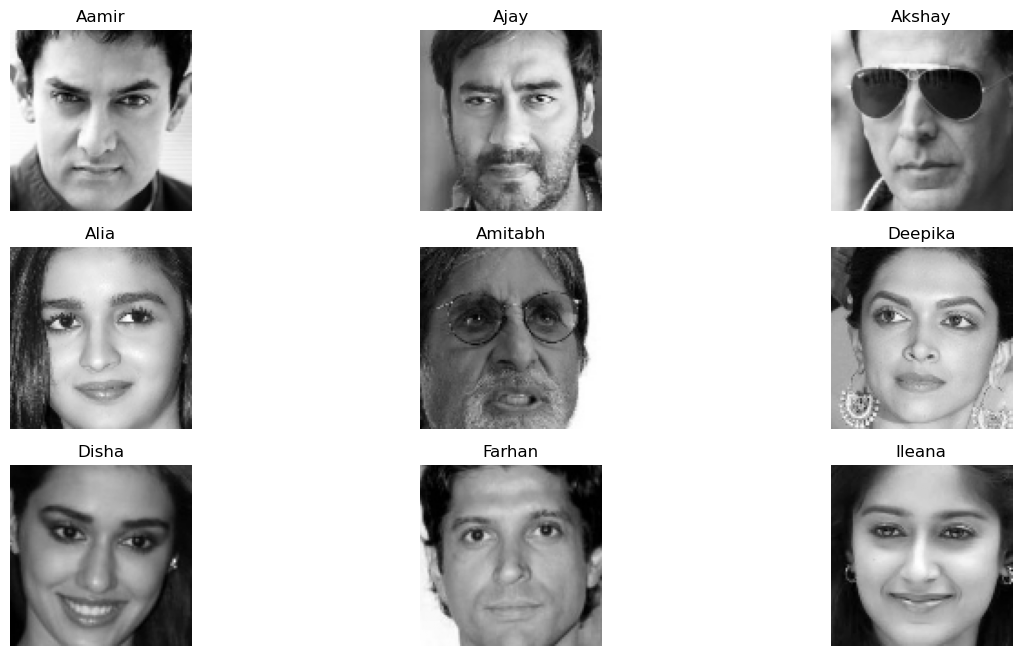

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

shown = set()
plot = 1

for i in range(len(labels)):
    if labels[i] not in shown:
        plt.subplot(3, 3, plot)
        plt.imshow(faces[i].reshape(100,100), cmap='gray')
        plt.title(names[labels[i]])
        plt.axis('off')

        shown.add(labels[i])
        plot += 1

    if plot > 9:
        break

plt.show()

In [22]:
X_train,X_test,y_train,y_test=train_test_split(
    faces,
    labels,
    test_size=0.4,
    random_state=42,
    stratify=labels
)

print(X_train.shape)
print(X_test.shape)

(270, 10000)
(180, 10000)


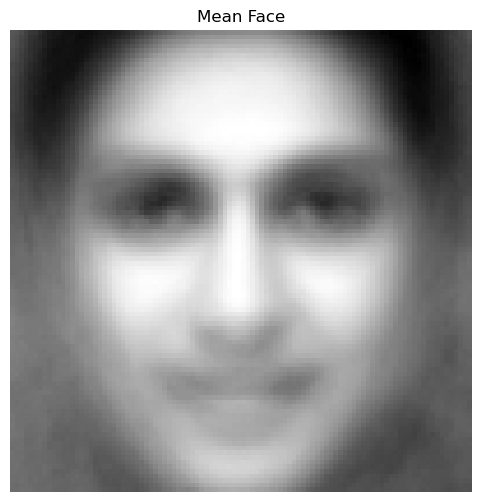

In [23]:
mean_face=np.mean(X_train,axis=0)

plt.imshow(mean_face.reshape(100,100),cmap='gray')

plt.title("Mean Face")

plt.axis("off")

plt.show()

In [24]:
from sklearn.decomposition import PCA

k = 100   


pca = PCA(
    n_components=k,
    whiten=True,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Training Features:", X_train_pca.shape)
print("Testing Features:", X_test_pca.shape)

Training Features: (270, 100)
Testing Features: (180, 100)


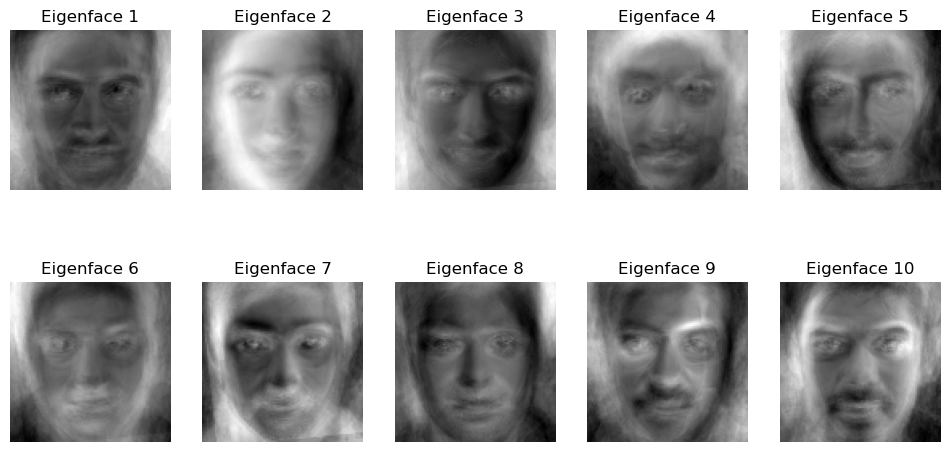

In [25]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        pca.components_[i].reshape(100,100),
        cmap='gray'
    )

    plt.title(f"Eigenface {i+1}")

    plt.axis('off')

plt.show()

In [26]:
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

ann.fit(X_train_pca, y_train)

print("ANN Training Completed Successfully!")

ANN Training Completed Successfully!


In [27]:
prediction = ann.predict(X_test_pca)

accuracy = accuracy_score(y_test, prediction)

print("Recognition Accuracy :", round(accuracy * 100, 2), "%")


Recognition Accuracy : 75.0 %


In [28]:
from sklearn.decomposition import PCA

k_values = [20, 40, 60, 80, 100, 120, 150, 180, 200]

accuracy_list = []

for k in k_values:

    pca = PCA(
        n_components=k,
        whiten=True,
        random_state=42
    )

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    ann = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    )

    ann.fit(X_train_pca, y_train)

    prediction = ann.predict(X_test_pca)

    acc = accuracy_score(y_test, prediction)

    accuracy_list.append(acc)

    print(f"k = {k:3d}  Accuracy = {acc*100:.2f}%")

k =  20  Accuracy = 62.22%
k =  40  Accuracy = 65.00%
k =  60  Accuracy = 65.00%
k =  80  Accuracy = 67.22%
k = 100  Accuracy = 71.11%
k = 120  Accuracy = 73.33%
k = 150  Accuracy = 68.33%
k = 180  Accuracy = 64.44%
k = 200  Accuracy = 65.56%


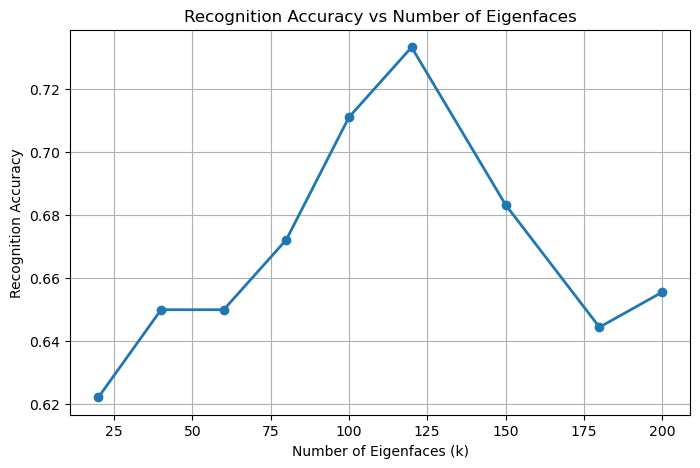

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracy_list,
    marker='o',
    linewidth=2
)

plt.title("Recognition Accuracy vs Number of Eigenfaces")

plt.xlabel("Number of Eigenfaces (k)")

plt.ylabel("Recognition Accuracy")

plt.grid(True)

plt.show()

In [30]:
best_index = np.argmax(accuracy_list)

best_k = k_values[best_index]

best_accuracy = accuracy_list[best_index]

print("Best k =", best_k)

print("Highest Accuracy =", round(best_accuracy*100,2), "%")

Best k = 120
Highest Accuracy = 73.33 %


In [31]:
pca = PCA(
    n_components=best_k,
    whiten=True,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

ann = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

ann.fit(X_train_pca, y_train)

prediction = ann.predict(X_test_pca)

In [34]:
import os
import cv2
import numpy as np

imposter_path = "dataset/dataset/imposter"

imposter_faces = []

for person in os.listdir(imposter_path):

    # Ignore hidden folders
    if person.startswith("."):
        continue

    person_path = os.path.join(imposter_path, person)

    if not os.path.isdir(person_path):
        continue

    for img_name in os.listdir(person_path):

        img_path = os.path.join(person_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (100,100))

        imposter_faces.append(img.flatten())

imposter_faces = np.array(imposter_faces)

print("Number of imposter images:", len(imposter_faces))

Number of imposter images: 33


In [35]:
# Assign label -1 to all imposters
unknown_labels = np.full(len(imposter_faces), -1)

# Combine known test images and imposters
X_test_new = np.vstack((X_test, imposter_faces))

y_test_new = np.concatenate((y_test, unknown_labels))

print("Known test images :", len(X_test))
print("Imposter images   :", len(imposter_faces))
print("Total test images :", len(X_test_new))

Known test images : 180
Imposter images   : 33
Total test images : 213


In [43]:
X_test_new_pca = pca.transform(X_test_new)
print(X_test_new_pca.shape)

(213, 120)


In [44]:
probabilities = ann.predict_proba(X_test_new_pca)

predictions = ann.predict(X_test_new_pca)

print(probabilities.shape)
print(predictions.shape)

(213, 9)
(213,)


In [60]:
threshold = 0.60

final_predictions = []

for i in range(len(X_test_new)):

    confidence = np.max(probabilities[i])

    if confidence < threshold:
        final_predictions.append("Not Enrolled")
    else:
        final_predictions.append(names[predictions[i]])

print(final_predictions[:20])

['Disha', 'Amitabh', 'Not Enrolled', 'Ileana', 'Not Enrolled', 'Not Enrolled', 'Ajay', 'Akshay', 'Deepika', 'Not Enrolled', 'Ileana', 'Akshay', 'Not Enrolled', 'Not Enrolled', 'Aamir', 'Not Enrolled', 'Ajay', 'Farhan', 'Ileana', 'Not Enrolled']


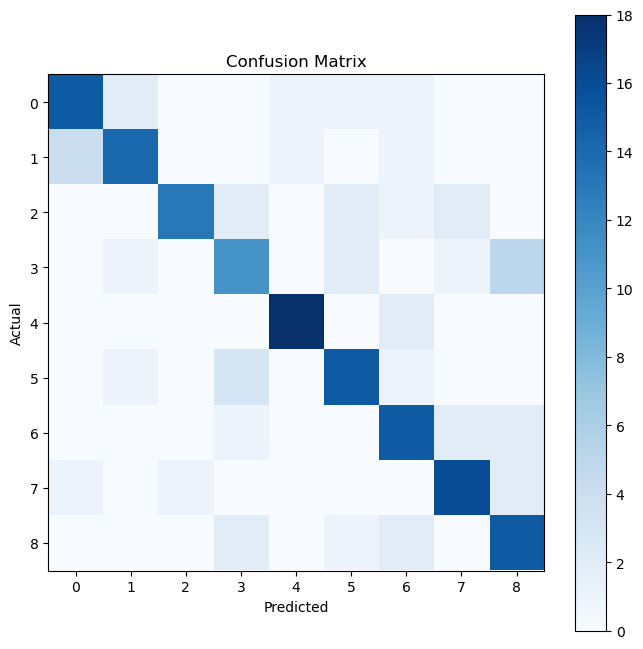

In [61]:
cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(8,8))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()

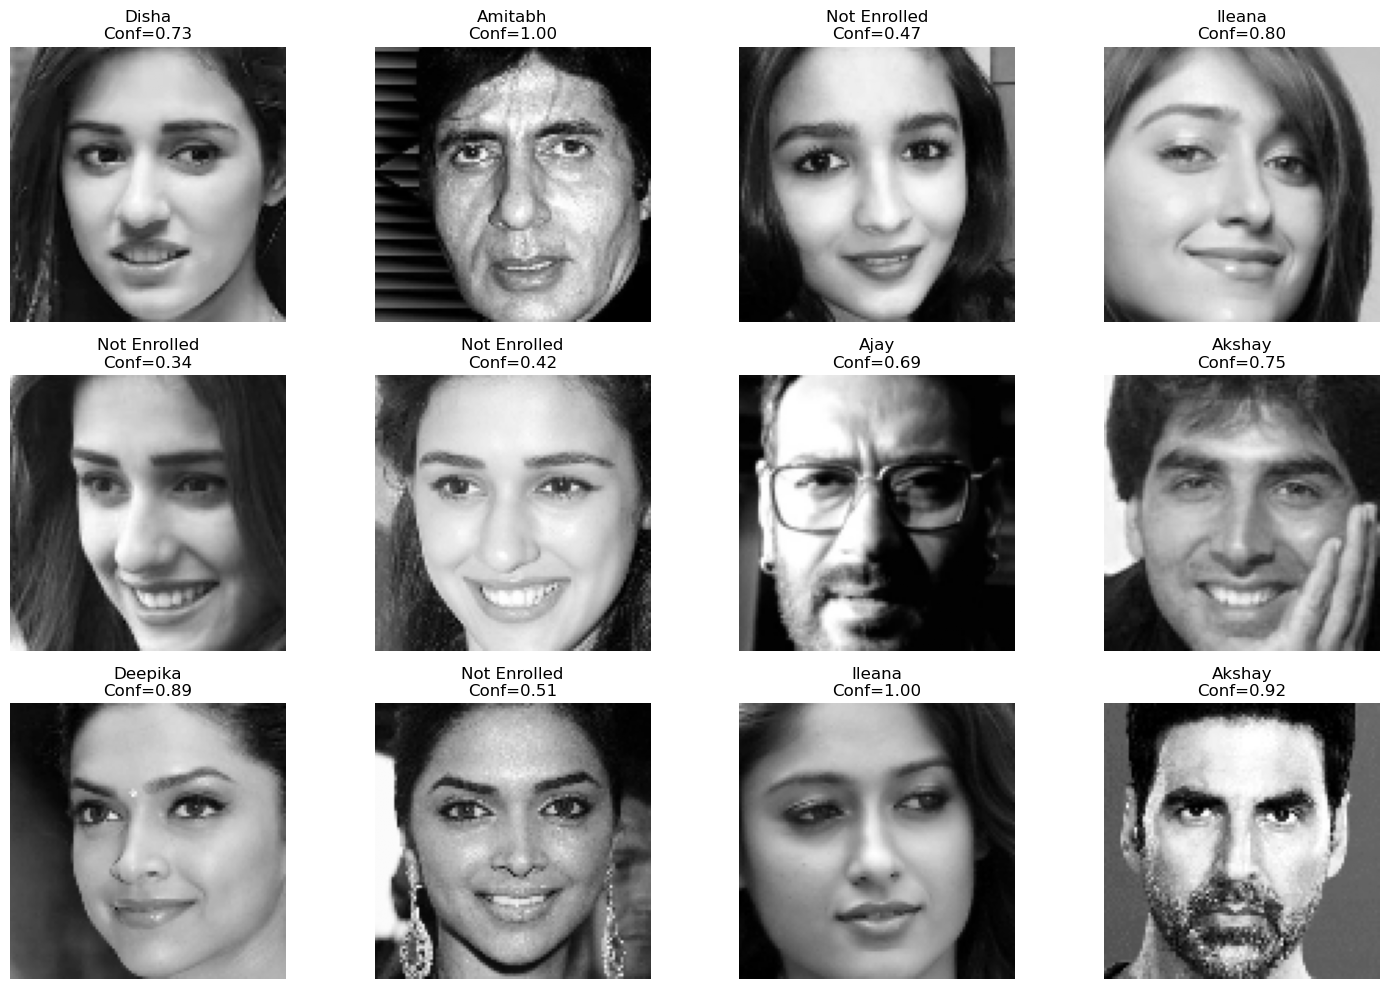

In [62]:
plt.figure(figsize=(15,10))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(X_test_new[i].reshape(100,100), cmap='gray')

    confidence = np.max(probabilities[i])
    
    plt.title(f"{final_predictions[i]}\nConf={confidence:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [63]:
correct_known = 0

for i in range(len(y_test)):

    if final_predictions[i] == names[y_test[i]]:
        correct_known += 1

known_accuracy = correct_known / len(y_test)

print("Known Accuracy:", known_accuracy)

Known Accuracy: 0.6333333333333333


In [64]:
correct_imposters = 0

for i in range(len(imposter_faces)):

    index = len(y_test) + i

    if final_predictions[index] == "Not Enrolled":
        correct_imposters += 1

idr = correct_imposters / len(imposter_faces)

print("🚫 Imposter Detection Rate:", round(idr*100,2), "%")

🚫 Imposter Detection Rate: 24.24 %


In [65]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    prediction,
    target_names=names
))

              precision    recall  f1-score   support

       Aamir       0.75      0.75      0.75        20
        Ajay       0.78      0.70      0.74        20
      Akshay       0.93      0.65      0.76        20
        Alia       0.58      0.55      0.56        20
     Amitabh       0.90      0.90      0.90        20
     Deepika       0.71      0.75      0.73        20
       Disha       0.65      0.75      0.70        20
      Farhan       0.76      0.80      0.78        20
      Ileana       0.62      0.75      0.68        20

    accuracy                           0.73       180
   macro avg       0.74      0.73      0.73       180
weighted avg       0.74      0.73      0.73       180

